In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report
import joblib

df = pd.read_csv("Customer-Churn.csv")
pd.set_option("display.max_columns",None)
df.isnull().sum()
df.duplicated().sum()
df.info()
df.shape
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [2]:
df["TotalCharges"] = df["TotalCharges"].replace({' ':0.0})
df["TotalCharges"] = df["TotalCharges"].astype(float)
df = df.drop(columns="customerID")

for col in df.columns:
    print(df[col].unique())
    print("-"*50)

['Female' 'Male']
--------------------------------------------------
[0 1]
--------------------------------------------------
['Yes' 'No']
--------------------------------------------------
['No' 'Yes']
--------------------------------------------------
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
['No' 'Yes']
--------------------------------------------------
['No phone service' 'No' 'Yes']
--------------------------------------------------
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['Yes' 'No' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
---------------------------------------

In [3]:
# printing values for categorical columns
numerical_features_list = ["tenure","MonthlyCharges","TotalCharges"]
for col in df.columns:
    if col not in numerical_features_list:
        print(df[col].unique())
        print("-"*50)

['Female' 'Male']
--------------------------------------------------
[0 1]
--------------------------------------------------
['Yes' 'No']
--------------------------------------------------
['No' 'Yes']
--------------------------------------------------
['No' 'Yes']
--------------------------------------------------
['No phone service' 'No' 'Yes']
--------------------------------------------------
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['Yes' 'No' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['No' 'Yes' 'No internet service']
--------------------------------------------------
['Mon

In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

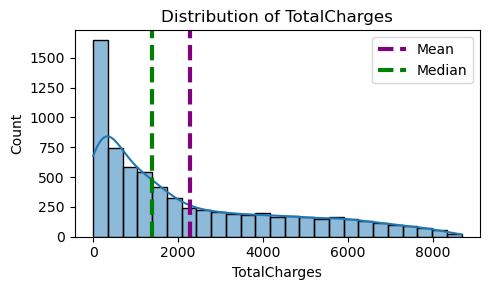

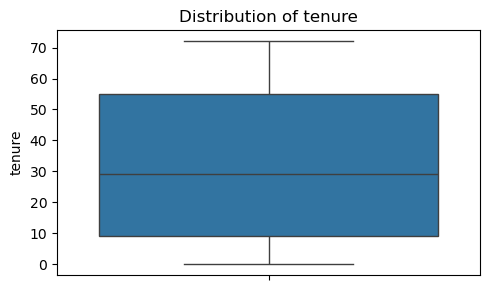

In [5]:
# Functions for plots

def box_plot(df,column_name):
    
    plt.figure(figsize=(5,3))
    
    sns.boxplot(y=df[column_name])
    plt.title(f"Distribution of {column_name}")
    
    plt.ylabel(column_name)
    plt.tight_layout()
    plt.show()
    
def plot_histogram(df,column_name):
    
    plt.figure(figsize=(5,3))
    sns.histplot(df[column_name],kde=True)
    plt.title(f"Distribution of {column_name}")
    
    plt.axvline(np.mean(df[column_name]),linestyle="--",linewidth=3,color="purple",label="Mean")
    plt.axvline(np.median(df[column_name]),linestyle="--",linewidth=3,color="green",label="Median")

    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_histogram(df,"TotalCharges")
box_plot(df,"tenure")

# correlation Heatmap for numerical columns

<Axes: >

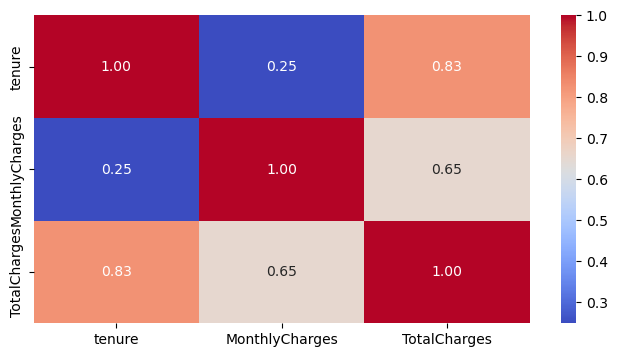

In [6]:
plt.figure(figsize=(8,4))
sns.heatmap(df[["tenure","MonthlyCharges","TotalCharges"]].corr(),annot=True,cmap="coolwarm",fmt=".2f")

In [7]:
object_columns = df.select_dtypes(include="object").columns.tolist()
object_columns = ["SeniorCitizen"] + object_columns

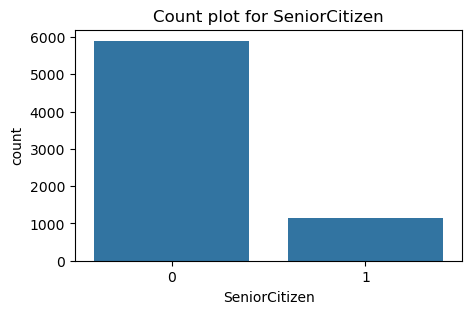

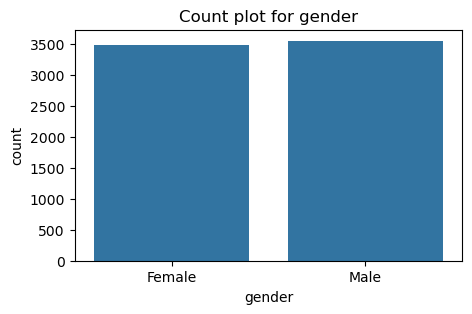

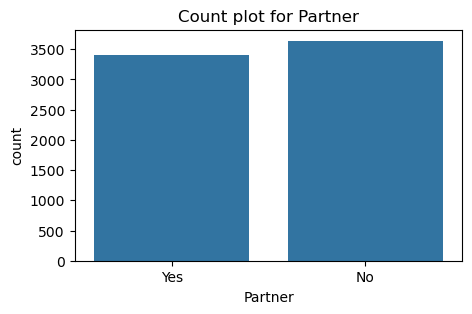

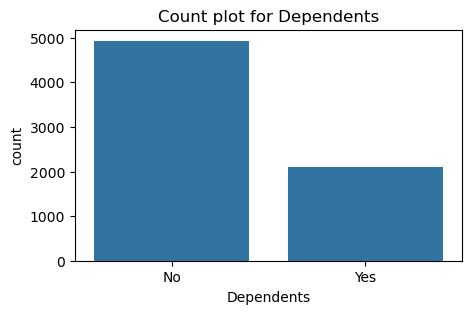

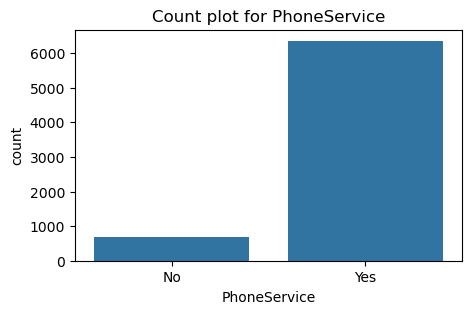

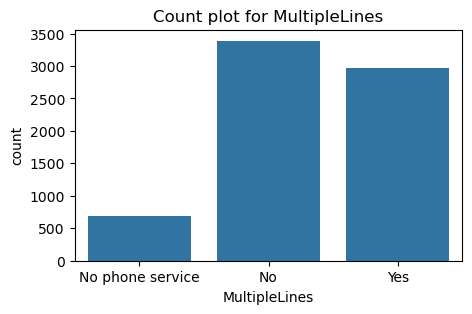

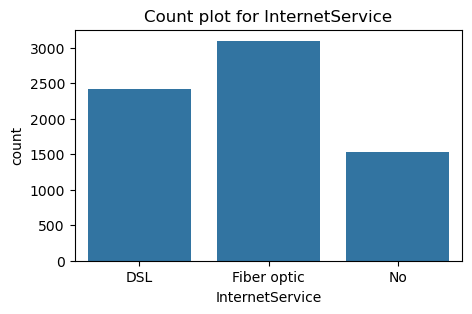

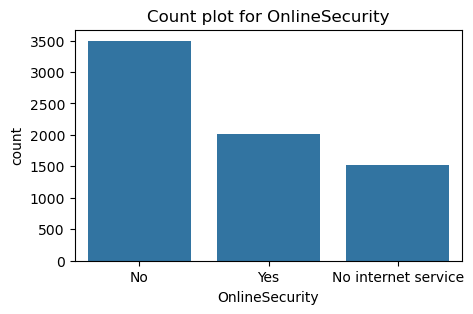

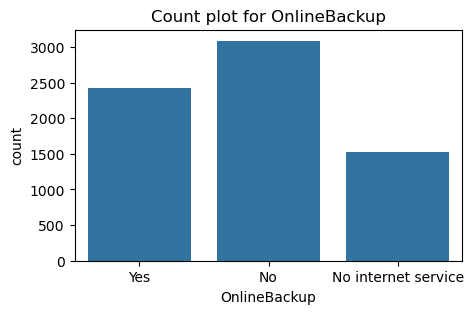

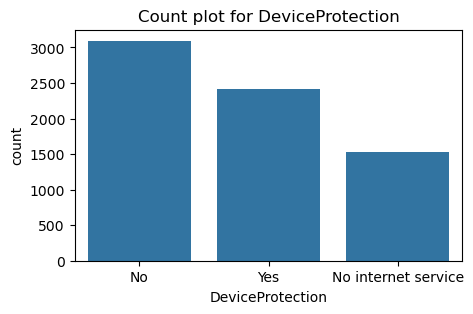

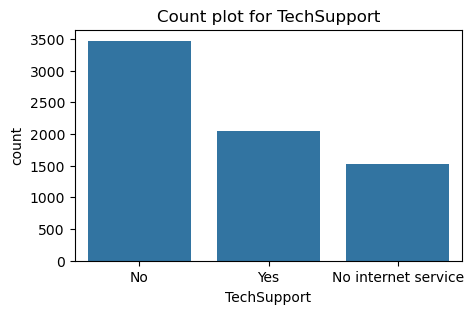

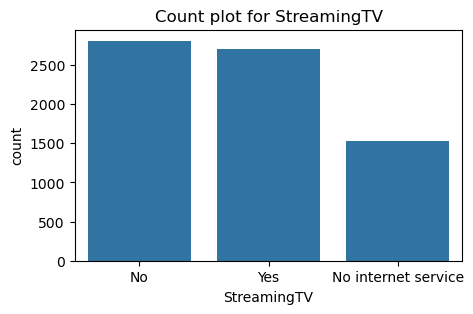

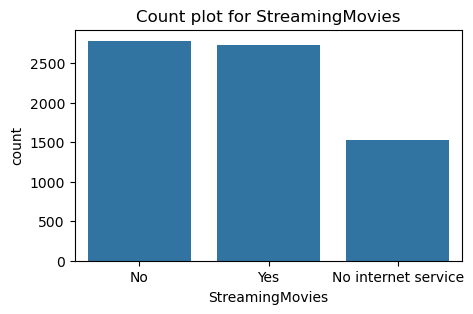

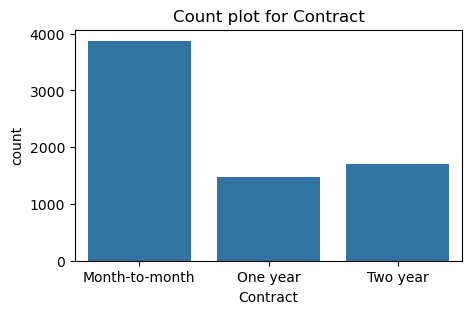

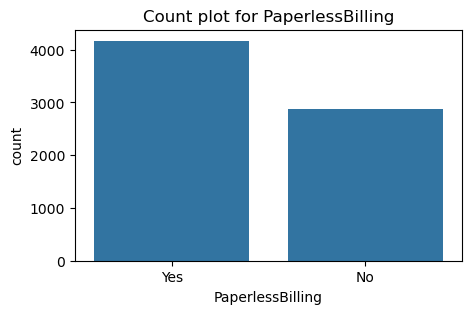

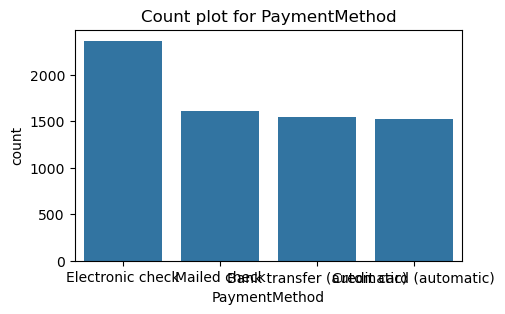

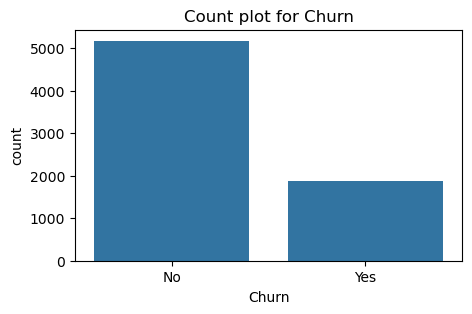

In [8]:
for col in object_columns:
    plt.figure(figsize=(5,3))
    sns.countplot(x=df[col])
    plt.title(f"Count plot for {col}")
    plt.show()

In [9]:
# Initializing dictionary to save the encoders
encoders = {}
for column in object_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

with open("encoders.joblib","wb") as f:
    joblib.dump(encoders,f)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [10]:
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

# Training and Test Data

In [11]:
df.to_csv("final_data.csv")
x = df.drop(columns="Churn")
y = df["Churn"]
print(x.shape,y.shape)

(7043, 19) (7043,)


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(5634, 19) (5634,) (1409, 19) (1409,)


# Applying Smote

In [13]:
smote = SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [14]:
print(y_train_smote.value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


In [15]:
# dictionary of models
models = {"Decision Tree" : DecisionTreeClassifier(random_state=42),
         "Randome Forest" : RandomForestClassifier(random_state=42),
         "XGBoost" : XGBClassifier(random_state=42)}
cv_scores = {}
for model_name,model in models.items():
    
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, x_train_smote, y_train_smote,cv=5, scoring="accuracy")
    
    cv_scores[model_name] = scores
    print(f"{model_name} cross validation accuracy: {np.mean(scores):.2f}")
    
    print("-"*50)

Training Decision Tree with default parameters
Decision Tree cross validation accuracy: 0.79
--------------------------------------------------
Training Randome Forest with default parameters
Randome Forest cross validation accuracy: 0.84
--------------------------------------------------
Training XGBoost with default parameters
XGBoost cross validation accuracy: 0.83
--------------------------------------------------


In [16]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(x_train_smote,y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Model Evaluation

In [17]:
y_test_pred = rfc.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test_pred,y_test)}")
print(f"Confusion matrix: {confusion_matrix(y_test_pred,y_test)}")
print(f"Classification Report: {classification_report(y_test_pred,y_test)}")

Accuracy Score: 0.7785663591199432
Confusion matrix: [[880 157]
 [155 217]]
Classification Report:               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1037
           1       0.58      0.58      0.58       372

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [18]:
model_data = {"model":rfc,"feature_names" : x.columns.to_list()}
with open("customer_churn_model.joblib","wb") as f:
    joblib.dump(model_data,f)

In [19]:
with open("customer_churn_model.joblib","rb") as f:
    model_data = joblib.load(f)
    
loaded_model = model_data["model"]
feature_names = model_data["feature_names"]

In [20]:
def predict_churn(customer_data):
    
    # Convert input dict to DataFrame
    input_df = pd.DataFrame([customer_data])
    
    if 'TotalCharges' in input_df.columns:
        input_df["TotalCharges"] = input_df["TotalCharges"].replace({' ': 0.0}).astype(float)
        
    for col, encoder in encoders.items():
        if col in input_df.columns:
            input_df[col] = encoder.transform(input_df[col])
            
    # Use the exact feature columns my model expects
    input_df = input_df[feature_names]
    prediction = loaded_model.predict(input_df)[0]
    
    if prediction == 1:
        print("The customer is likely to CHURN!")
    else:
        print("The customer is likely to STAY.")

new_customer = {
    'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No', 'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No', 'OnlineBackup': 'No', 'DeviceProtection': 'No', 'TechSupport': 'No',
    'StreamingTV': 'Yes', 'StreamingMovies': 'No', 'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 
    'MonthlyCharges': 70.7, 'TotalCharges': '151.65'
}

predict_churn(new_customer)

The customer is likely to CHURN!
